### import library

In [1]:
!pip install transformers datasets accelerate scikit-learn openpyxl seaborn -q

import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    multilabel_confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.11.0+cu128


### explorasi data & load json

In [2]:
filename = 'absa_labeled_gab.json'

with open(filename, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

ASPEK_COLS = ['produk', 'layanan', 'pengiriman']

print(f'Total review: {len(raw_data)}')
print(f'\nContoh record:')
print(json.dumps(raw_data[0], ensure_ascii=False, indent=2))

print('\n=== Distribusi Aspek ===')
for a in ASPEK_COLS:
    n = sum(1 for d in raw_data if d.get(a) is not None)
    print(f'  {a:12s}: {n} ({n/len(raw_data)*100:.1f}%)')

print('\n=== Distribusi Polarity per Aspek ===')
from collections import Counter
for a in ASPEK_COLS:
    pol = Counter(d[a]['polarity'] for d in raw_data if d.get(a) is not None)
    print(f'  {a:12s}: {dict(pol)}')

Total review: 2937

Contoh record:
{
  "clean_content": "banyak bantu dalam jual beli produk kualitas harga ringan di kantong terima kasih shopee",
  "layanan": {
    "text": "banyak bantu dalam jual beli",
    "polarity": "positif"
  },
  "pengiriman": null,
  "produk": {
    "text": "kualitas harga ringan di kantong",
    "polarity": "positif"
  },
  "other": null
}

=== Distribusi Aspek ===
  produk      : 786 (26.8%)
  layanan     : 1492 (50.8%)
  pengiriman  : 824 (28.1%)

=== Distribusi Polarity per Aspek ===
  produk      : {'positif': 575, 'netral': 7, 'negatif': 204}
  layanan     : {'positif': 536, 'negatif': 932, 'netral': 24}
  pengiriman  : {'positif': 377, 'negatif': 433, 'netral': 14}


### preprocessing dataset bagian aspek

In [3]:
aspek_records = []
for d in raw_data:
    row = {
        'clean_content': d['clean_content'],
        'produk':        1 if d.get('produk')     is not None else 0,
        'layanan':       1 if d.get('layanan')    is not None else 0,
        'pengiriman':    1 if d.get('pengiriman') is not None else 0,
    }
    aspek_records.append(row)

df_aspek = pd.DataFrame(aspek_records)
df_aspek = df_aspek[df_aspek[ASPEK_COLS].sum(axis=1) > 0].reset_index(drop=True)

print(f'Dataset Aspek — Total review: {len(df_aspek)}')
for a in ASPEK_COLS:
    print(f'   {a:12s}: {df_aspek[a].sum()} ({df_aspek[a].mean()*100:.1f}%)')

combo = df_aspek[ASPEK_COLS].apply(
    lambda r: '+'.join([a for a in ASPEK_COLS if r[a]==1]), axis=1
)
print('\nKombinasi aspek:')
print(combo.value_counts().to_string())

Dataset Aspek — Total review: 2160
   produk      : 786 (36.4%)
   layanan     : 1492 (69.1%)
   pengiriman  : 824 (38.1%)

Kombinasi aspek:
layanan                      842
layanan+pengiriman           274
produk+layanan               268
pengiriman                   258
produk                       226
produk+pengiriman            184
produk+layanan+pengiriman    108


### preprocessing dataset bagian sentimen

In [4]:
SENTIMEN_LABEL    = {'positif': 0, 'negatif': 1}
SENTIMEN_ID2LABEL = {0: 'positif', 1: 'negatif'}
SENTIMEN_VALID    = ['positif', 'negatif']

sent_records = []
for d in raw_data:
    clean = d['clean_content']
    for aspek in ASPEK_COLS:
        if d.get(aspek) is not None:
            span     = d[aspek].get('text', '').strip()
            polarity = d[aspek].get('polarity', '').lower().strip()
            if polarity not in SENTIMEN_VALID:
                continue
            sent_records.append({
                'clean_content': clean,   # <-- INPUT MODEL SENTIMEN (full review)
                'aspek':         aspek,
                'span':          span,    # disimpan tapi tidak dipakai untuk training
                'polarity':      polarity,
                'sentimen_label':SENTIMEN_LABEL[polarity]
            })

df_sent = pd.DataFrame(sent_records).reset_index(drop=True)

print(f'Dataset Sentimen (Full Text):')
print(f'   Total pasangan (review, aspek): {len(df_sent)}')
print(f'\nDistribusi polarity:')
print(df_sent['polarity'].value_counts().to_string())
print(f'\nDistribusi polarity per aspek:')
print(df_sent.groupby(['aspek','polarity']).size().to_string())
print(f'\nContoh input (full review) per aspek:')
for _, row in df_sent.head(4).iterrows():
    print(f'   [{row.aspek}] "{row.clean_content[:60]}..." -> {row.polarity}')

Dataset Sentimen (Full Text):
   Total pasangan (review, aspek): 3057

Distribusi polarity:
polarity
negatif    1569
positif    1488

Distribusi polarity per aspek:
aspek       polarity
layanan     negatif     932
            positif     536
pengiriman  negatif     433
            positif     377
produk      negatif     204
            positif     575

Contoh input (full review) per aspek:
   [produk] "banyak bantu dalam jual beli produk kualitas harga ringan di..." -> positif
   [layanan] "banyak bantu dalam jual beli produk kualitas harga ringan di..." -> positif
   [pengiriman] "ayo teman teman kita mendownload shopee karena aplikasi ini ..." -> positif
   [produk] "aplikasi belanja mudah segala sesuatu kebutuhan ada penjual ..." -> positif


### split data aspek dan sentimen

In [5]:
# Split Aspek
stratify_aspek = df_aspek[ASPEK_COLS].astype(str).agg(''.join, axis=1)
train_aspek, temp_aspek = train_test_split(
    df_aspek, test_size=0.2, random_state=42, stratify=stratify_aspek
)
val_aspek, test_aspek = train_test_split(
    temp_aspek, test_size=0.5, random_state=42,
    stratify=temp_aspek[ASPEK_COLS].astype(str).agg(''.join, axis=1)
)
train_aspek = train_aspek.reset_index(drop=True)
val_aspek   = val_aspek.reset_index(drop=True)
test_aspek  = test_aspek.reset_index(drop=True)

# Split Sentimen
stratify_sent = df_sent['aspek'] + '_' + df_sent['polarity']
train_sent, temp_sent = train_test_split(
    df_sent, test_size=0.2, random_state=42, stratify=stratify_sent
)
val_sent, test_sent = train_test_split(
    temp_sent, test_size=0.5, random_state=42,
    stratify=temp_sent['aspek'] + '_' + temp_sent['polarity']
)
train_sent = train_sent.reset_index(drop=True)
val_sent   = val_sent.reset_index(drop=True)
test_sent  = test_sent.reset_index(drop=True)

print('Split selesai!')
print(f'[ASPEK]    Train={len(train_aspek)} | Val={len(val_aspek)} | Test={len(test_aspek)}')
print(f'[SENTIMEN] Train={len(train_sent)} | Val={len(val_sent)} | Test={len(test_sent)}')

Split selesai!
[ASPEK]    Train=1728 | Val=216 | Test=216
[SENTIMEN] Train=2445 | Val=306 | Test=306


### class & trainer

In [6]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

class AspekDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class MultilabelTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

class WeightedSentimenTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print('Dataset class & Trainer siap!')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Dataset class & Trainer siap!


### training model aspek

In [7]:
pos_counts = train_aspek[ASPEK_COLS].sum().values
neg_counts = len(train_aspek) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float).to(device)

train_labels_aspek = train_aspek[ASPEK_COLS].values.tolist()
val_labels_aspek   = val_aspek[ASPEK_COLS].values.tolist()
test_labels_aspek  = test_aspek[ASPEK_COLS].values.tolist()

ds_train_aspek = AspekDataset(train_aspek['clean_content'].tolist(), train_labels_aspek, tokenizer)
ds_val_aspek   = AspekDataset(val_aspek['clean_content'].tolist(),   val_labels_aspek,   tokenizer)
ds_test_aspek  = AspekDataset(test_aspek['clean_content'].tolist(),  test_labels_aspek,  tokenizer)

model_aspek = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(ASPEK_COLS),
    problem_type='multi_label_classification',
    id2label={i: a for i, a in enumerate(ASPEK_COLS)},
    label2id={a: i for i, a in enumerate(ASPEK_COLS)}
)



# ===============================
# FREEZE LAYER BERT
# ===============================
for param in model_aspek.bert.embeddings.parameters():
    param.requires_grad = False

for layer in model_aspek.bert.encoder.layer[:12]:
    for param in layer.parameters():
        param.requires_grad = False


args_aspek = TrainingArguments(
    output_dir='./model_aspek',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer_aspek = MultilabelTrainer(
    pos_weight=pos_weight,
    model=model_aspek,
    args=args_aspek,
    train_dataset=ds_train_aspek,
    eval_dataset=ds_val_aspek,
)

print('Training Model Aspek...')
trainer_aspek.train()
print('Training Model Aspek selesai!')

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Model Aspek selesai!


### evaluasi model aspek

EVALUASI MODEL ASPEK - Multi-label
thr=0.3: P=0.520 R=0.981 F1-micro=0.680 F1-macro=0.664
thr=0.4: P=0.590 R=0.875 F1-micro=0.705 F1-macro=0.695
thr=0.5: P=0.656 R=0.704 F1-micro=0.679 F1-macro=0.674
thr=0.6: P=0.762 R=0.556 F1-micro=0.643 F1-macro=0.634
thr=0.7: P=0.769 R=0.534 F1-micro=0.630 F1-macro=0.619

Best threshold: 0.4

Classification Report (threshold=0.4):
              precision    recall  f1-score   support

      produk       0.54      0.86      0.67        80
     layanan       0.77      0.84      0.80       149
  pengiriman       0.46      0.95      0.62        82

   micro avg       0.59      0.87      0.70       311
   macro avg       0.59      0.88      0.69       311
weighted avg       0.63      0.87      0.72       311
 samples avg       0.64      0.89      0.71       311

Subset Accuracy (Exact Match): 0.3148


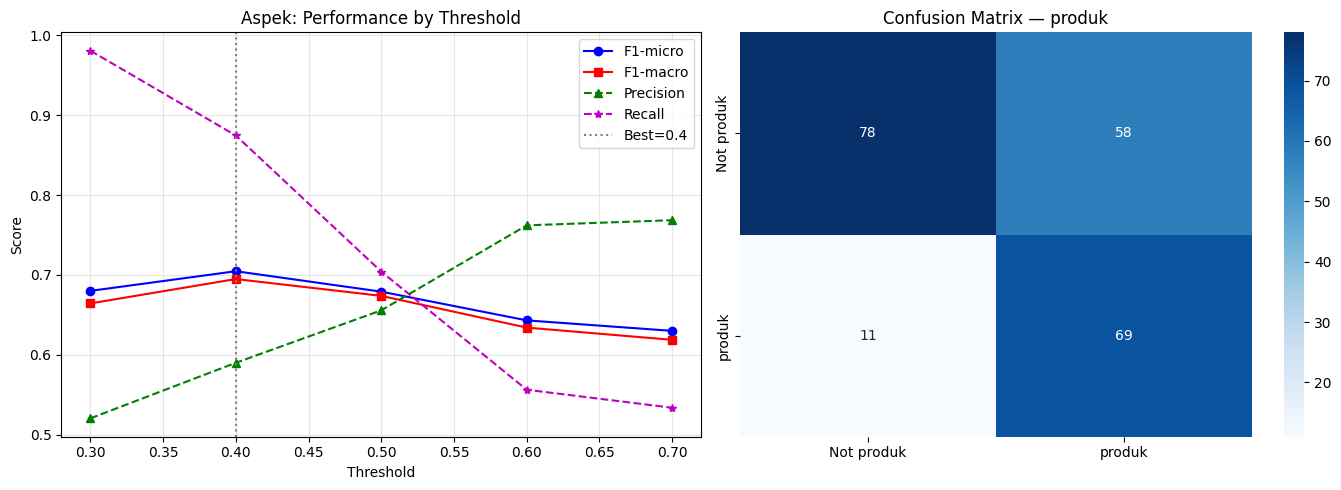

In [8]:
preds_out    = trainer_aspek.predict(ds_test_aspek)
logits       = preds_out.predictions
probs        = torch.sigmoid(torch.tensor(logits)).numpy()
y_true_aspek = np.array(test_labels_aspek)

print('=' * 60)
print('EVALUASI MODEL ASPEK - Multi-label')
print('=' * 60)

thresholds  = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_results = []
for thr in thresholds:
    y_pred    = (probs >= thr).astype(int)
    zero_mask = y_pred.sum(axis=1) == 0
    y_pred[zero_mask, np.argmax(probs[zero_mask], axis=1)] = 1
    f1_mi = f1_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    f1_ma = f1_score(y_true_aspek, y_pred, average='macro', zero_division=0)
    pr    = precision_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    rc    = recall_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    thr_results.append({'Threshold': thr, 'Precision': pr, 'Recall': rc, 'F1-micro': f1_mi, 'F1-macro': f1_ma})
    print(f'thr={thr}: P={pr:.3f} R={rc:.3f} F1-micro={f1_mi:.3f} F1-macro={f1_ma:.3f}')

thr_df         = pd.DataFrame(thr_results)
best_thr       = thr_df.loc[thr_df['F1-micro'].idxmax(), 'Threshold']
BEST_THRESHOLD = best_thr
print(f'\nBest threshold: {best_thr}')

y_pred_best = (probs >= best_thr).astype(int)
zero_mask   = y_pred_best.sum(axis=1) == 0
y_pred_best[zero_mask, np.argmax(probs[zero_mask], axis=1)] = 1

print(f'\nClassification Report (threshold={best_thr}):')
print(classification_report(y_true_aspek, y_pred_best, target_names=ASPEK_COLS, zero_division=0))

from sklearn.metrics import accuracy_score
subset_acc = accuracy_score(y_true_aspek, y_pred_best)
print(f'Subset Accuracy (Exact Match): {subset_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thr_df['Threshold'], thr_df['F1-micro'],  'bo-', label='F1-micro')
axes[0].plot(thr_df['Threshold'], thr_df['F1-macro'],  'rs-', label='F1-macro')
axes[0].plot(thr_df['Threshold'], thr_df['Precision'], 'g^--', label='Precision')
axes[0].plot(thr_df['Threshold'], thr_df['Recall'],    'm*--', label='Recall')
axes[0].axvline(x=best_thr, color='gray', linestyle=':', label=f'Best={best_thr}')
axes[0].set_title('Aspek: Performance by Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

mcm = multilabel_confusion_matrix(y_true_aspek, y_pred_best)
sns.heatmap(mcm[0], annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not '+ASPEK_COLS[0], ASPEK_COLS[0]],
            yticklabels=['Not '+ASPEK_COLS[0], ASPEK_COLS[0]])
axes[1].set_title(f'Confusion Matrix — {ASPEK_COLS[0]}')
plt.tight_layout()
plt.savefig('eval_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
thr_df.to_excel('threshold_aspek.xlsx', index=False)

### training model sentimen

In [9]:
SENTIMEN_LABEL    = {'positif': 0, 'negatif': 1}
SENTIMEN_ID2LABEL = {0: 'positif', 1: 'negatif'}
NUM_SENTIMEN      = 2

train_sent = train_sent[train_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)
val_sent   = val_sent[val_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)
test_sent  = test_sent[test_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)

train_sent['sentimen_label'] = train_sent['polarity'].map(SENTIMEN_LABEL)
val_sent['sentimen_label']   = val_sent['polarity'].map(SENTIMEN_LABEL)
test_sent['sentimen_label']  = test_sent['polarity'].map(SENTIMEN_LABEL)

cw        = compute_class_weight('balanced', classes=np.arange(NUM_SENTIMEN), y=train_sent['sentimen_label'].values)
cw_tensor = torch.tensor(cw, dtype=torch.float).to(device)

# FULL REVIEW sebagai input (bukan span)
ds_train_sent = SentimenDataset(train_sent['clean_content'].tolist(), train_sent['sentimen_label'].tolist(), tokenizer)
ds_val_sent   = SentimenDataset(val_sent['clean_content'].tolist(),   val_sent['sentimen_label'].tolist(),   tokenizer)
ds_test_sent  = SentimenDataset(test_sent['clean_content'].tolist(),  test_sent['sentimen_label'].tolist(),  tokenizer)

model_sentimen_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_SENTIMEN,
    id2label=SENTIMEN_ID2LABEL, label2id=SENTIMEN_LABEL
)

# ===============================
# FREEZE LAYER BERT
# ===============================
for param in model_sentimen_full.bert.embeddings.parameters():
    param.requires_grad = False

for layer in model_sentimen_full.bert.encoder.layer[:12]:
    for param in layer.parameters():
        param.requires_grad = False

args_sent_full = TrainingArguments(
    output_dir='./model_sentimen_full',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer_sent_full = WeightedSentimenTrainer(
    class_weights=cw_tensor,
    model=model_sentimen_full,
    args=args_sent_full,
    train_dataset=ds_train_sent,
    eval_dataset=ds_val_sent,
)

print('Training Model Sentimen — IndoBERT FULL TEXT...')
print(f'Input: full review (clean_content)')
print(f'Train={len(ds_train_sent)} | Val={len(ds_val_sent)} | Test={len(ds_test_sent)}')
trainer_sent_full.train()
print('Training selesai!')

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Model Sentimen — IndoBERT FULL TEXT...
Input: full review (clean_content)
Train=2445 | Val=306 | Test=306


Epoch,Training Loss,Validation Loss
1,0.487625,0.393885
2,0.338145,0.291185
3,0.344589,0.264622
4,0.348347,0.252601
5,0.310670,0.250103


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai!


### evaluasi model sentimen

EVALUASI MODEL SENTIMEN — IndoBERT FULL TEXT
              precision    recall  f1-score   support

     positif       0.87      0.88      0.88       149
     negatif       0.88      0.88      0.88       157

    accuracy                           0.88       306
   macro avg       0.88      0.88      0.88       306
weighted avg       0.88      0.88      0.88       306

Evaluasi per aspek:
  produk      : F1=0.863 | Acc=0.859 | n=78
  layanan     : F1=0.905 | Acc=0.905 | n=147
  pengiriman  : F1=0.852 | Acc=0.852 | n=81

Ringkasan — F1 weighted: 0.8791 | Accuracy: 0.8791


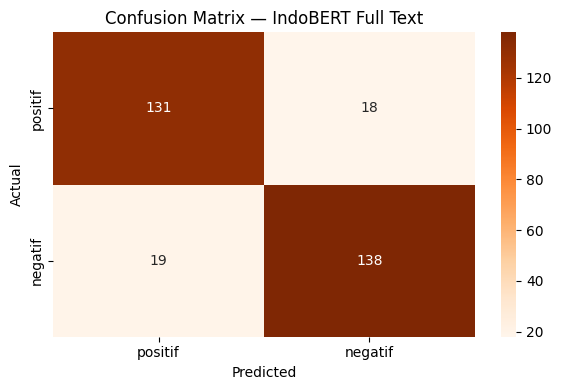

In [10]:
preds_full  = trainer_sent_full.predict(ds_test_sent)
y_pred_full = np.argmax(preds_full.predictions, axis=1)
y_true_sent = test_sent['sentimen_label'].values

print('=' * 55)
print('EVALUASI MODEL SENTIMEN — IndoBERT FULL TEXT')
print('=' * 55)
print(classification_report(y_true_sent, y_pred_full, target_names=list(SENTIMEN_LABEL.keys()), zero_division=0))

print('Evaluasi per aspek:')
for aspek in ASPEK_COLS:
    mask = (test_sent['aspek'] == aspek).values
    if mask.sum() == 0: continue
    f1  = f1_score(y_true_sent[mask], y_pred_full[mask], average='weighted', zero_division=0)
    acc = (y_true_sent[mask] == y_pred_full[mask]).mean()
    print(f'  {aspek:12s}: F1={f1:.3f} | Acc={acc:.3f} | n={mask.sum()}')

# Simpan metrik untuk perbandingan nanti
f1_full  = f1_score(y_true_sent, y_pred_full, average='weighted', zero_division=0)
acc_full = (y_true_sent == y_pred_full).mean()
print(f'\nRingkasan — F1 weighted: {f1_full:.4f} | Accuracy: {acc_full:.4f}')

cm = confusion_matrix(y_true_sent, y_pred_full)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=list(SENTIMEN_LABEL.keys()),
            yticklabels=list(SENTIMEN_LABEL.keys()))
plt.title('Confusion Matrix — IndoBERT Full Text')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('eval_sentimen_full.png', dpi=150, bbox_inches='tight')
plt.show()

### pipeline coba coba

In [11]:
def absa_pipeline_full(reviews, model_aspek, model_sentimen, tokenizer,
                       aspek_threshold=0.4, device='cpu'):
    model_aspek.eval().to(device)
    model_sentimen.eval().to(device)
    results = []
    for review in reviews:
        # Step 1: Prediksi Aspek dari full review
        enc = tokenizer(str(review), max_length=128, padding='max_length',
                        truncation=True, return_tensors='pt').to(device)
        with torch.no_grad():
            probs_aspek = torch.sigmoid(model_aspek(**enc).logits).cpu().numpy()[0]

        aspek_probs = {a: round(float(p), 3) for a, p in zip(ASPEK_COLS, probs_aspek)}
        aspek_aktif = [a for a, p in zip(ASPEK_COLS, probs_aspek) if p >= aspek_threshold]
        if not aspek_aktif:
            aspek_aktif = [ASPEK_COLS[np.argmax(probs_aspek)]]

        # Step 2: Prediksi Sentimen — input full review
        # Konsisten dengan training yang juga pakai full review
        sentimen_per_aspek = {}
        for aspek in aspek_aktif:
            enc_s = tokenizer(str(review), max_length=128, padding='max_length',
                              truncation=True, return_tensors='pt').to(device)
            with torch.no_grad():
                probs_s = torch.softmax(model_sentimen(**enc_s).logits, dim=-1).cpu().numpy()[0]
            pred_label = SENTIMEN_ID2LABEL[int(np.argmax(probs_s))]
            sentimen_per_aspek[aspek] = {'label': pred_label, 'confidence': round(float(max(probs_s)), 3)}

        results.append({
            'review':      review,
            'aspek_probs': aspek_probs,
            'aspek_aktif': aspek_aktif,
            'sentimen':    sentimen_per_aspek
        })
    return results

demo = [
    "barang bagus kualitas oke tapi pengiriman lambat banget",
    "penjual ramah respon cepat barang sesuai deskripsi",
    "paket rusak waktu sampai penjual tidak mau tanggung jawab",
    "sangat puas semua oke dari produk sampai pengiriman",
]

print('Demo Pipeline ABSA — IndoBERT Full Text:')
print('=' * 65)
res = absa_pipeline_full(demo, model_aspek, model_sentimen_full, tokenizer, device=device)
for r in res:
    print(f'\nReview: "{r["review"]}"')
    print(f'  Aspek aktif: {r["aspek_aktif"]}')
    for aspek, sent in r['sentimen'].items():
        print(f'  -> {aspek:12s}: {sent["label"]} (conf={sent["confidence"]})')

Demo Pipeline ABSA — IndoBERT Full Text:

Review: "barang bagus kualitas oke tapi pengiriman lambat banget"
  Aspek aktif: ['produk', 'pengiriman']
  -> produk      : positif (conf=0.748)
  -> pengiriman  : positif (conf=0.748)

Review: "penjual ramah respon cepat barang sesuai deskripsi"
  Aspek aktif: ['produk', 'pengiriman']
  -> produk      : positif (conf=0.767)
  -> pengiriman  : positif (conf=0.767)

Review: "paket rusak waktu sampai penjual tidak mau tanggung jawab"
  Aspek aktif: ['produk', 'layanan', 'pengiriman']
  -> produk      : negatif (conf=0.892)
  -> layanan     : negatif (conf=0.892)
  -> pengiriman  : negatif (conf=0.892)

Review: "sangat puas semua oke dari produk sampai pengiriman"
  Aspek aktif: ['produk', 'pengiriman']
  -> produk      : positif (conf=0.991)
  -> pengiriman  : positif (conf=0.991)
